In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from sklearn.datasets import load_diabetes 
import matplotlib.pyplot as plt
import numpy as np

from asa.correlation_methods import get_RF_importance
from asa.dataset import Dataset

## Use dataset

In [3]:
data = load_diabetes()

dataset = Dataset(np.hstack((data.data, data.target[:, None])), data.feature_names + ['diabetes'])

In [4]:
dataset.get_RF_importance.__doc__

Check the result:
  Train score:  0.9128921390803081
  Test score:  0.4246994839843985


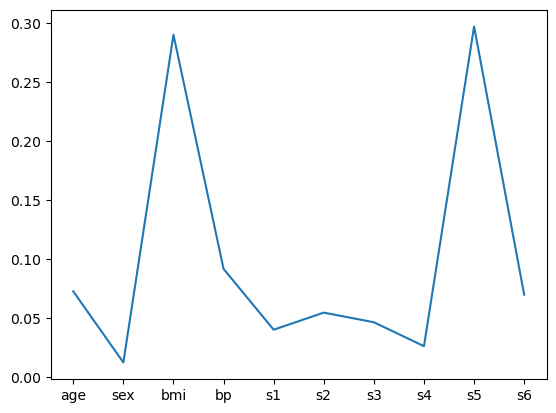

In [5]:
importance = dataset.get_RF_importance(
    ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
    'diabetes',
    problem_type='regression',
    RF_kwargs={
        'n_estimators': 1000,
        'max_depth': 10
    })

plt.plot(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], importance)


In [10]:
importance = dataset.get_RF_importance(
    ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
    'diabetes',
    problem_type='regression',
    RF_kwargs={
        'n_estimators': 100,
        'max_depth': 20
    },
    importance_type='permutation')

Check the result:
  Train score:  0.9176913437400851
  Test score:  0.4128283203756855


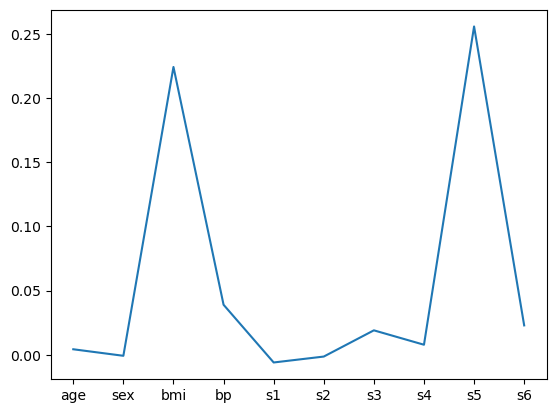

In [11]:
plt.plot(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
         importance.importances_mean)

## Use func

In [7]:
# generate regression data
data = load_diabetes()

In [10]:
x = data['data']
y = data['target']
x_label = data['feature_names']

In [41]:
feature_importance, rf, X_train, X_test, y_train, y_test = get_RF_importance(
    x,
    y,
    'regression',
    return_more=True,
    RF_kwargs={
        'n_estimators': 1000,
        'max_depth': 3,
        'random_state': 0
    })

In [42]:
rf.score(X_train, y_train)

0.5777904755852185

In [43]:
rf.score(X_test, y_test)

0.4917843594877097

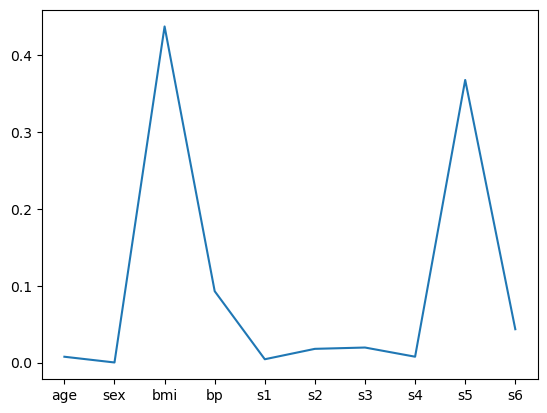

In [44]:
plt.plot(x_label, feature_importance)

In [45]:
feature_importance, rf, X_train, X_test, y_train, y_test = get_RF_importance(
    x, y, 'regression', return_more=True, importance_type='permutation')

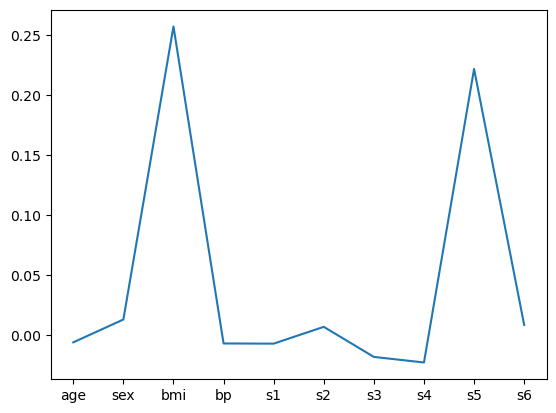

In [48]:
plt.plot(x_label, feature_importance.importances_mean)